<a href="https://colab.research.google.com/github/meghameghana3010-commits/Customer-Segmentation/blob/main/DiaBetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows of dataset:
         Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin  \
1354778            0      171             80             34       23   
1147438            8       92             93             47       36   
1640031            7      115             47             52       35   
1883350            9      103             78             25      304   
1424119            1       85             59             27       35   

               BMI  DiabetestPedigreeFunction  Age  Outcome  
1354778  43.509726                   1.213191   21        0  
1147438  21.240576                   0.158365   23        0  
1640031  41.511523                   0.079019   23        0  
1883350  29.582192                   1.282870   43        1  
1424119  42.604536                   0.549542   22        0  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
Index: 15000 entries, 1354778 to 1386396
Data columns (total 9 columns):
 #   Column                     Non-N

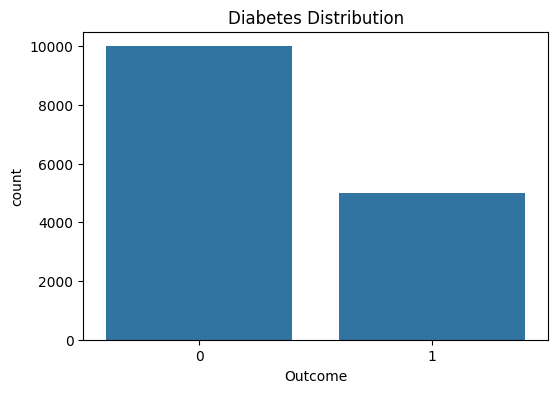


Model Accuracy: 0.7893333333333333

Confusion Matrix:
[[1810  204]
 [ 428  558]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.90      0.85      2014
           1       0.73      0.57      0.64       986

    accuracy                           0.79      3000
   macro avg       0.77      0.73      0.74      3000
weighted avg       0.78      0.79      0.78      3000



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

url = "/content/diabetes.csv"

columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetestPedigreeFunction",
    "Age",
    "Outcome"
]

# Read the CSV, skipping the first row (which is the actual header) and assign custom column names.
df = pd.read_csv(url, names=columns, skiprows=1)

# Convert all columns to numeric types. 'Outcome' should also be numeric for the model.
# Using errors='coerce' will turn non-convertible values into NaN.
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows with NaN values if any, as LogisticRegression cannot handle them directly.
# Alternatively, imputation could be used.
df.dropna(inplace=True)

print("First 5 rows of dataset:")
print(df.head())

print("\nDataset Information:")
print(df.info())

print("\nDataset Description:")
print(df.describe())

plt.figure(figsize=(6,4))
sns.countplot(x="Outcome", data=df)
plt.title("Diabetes Distribution")
plt.show()

X=df.drop("Outcome", axis=1)
Y=df["Outcome"]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
    )


model=LogisticRegression(max_iter=1000)
model.fit(X_train, Y_train)

predictions = model.predict(X_test)

accuracy = accuracy_score(Y_test,predictions)
print("\nModel Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, predictions))

print("\nClassification Report:")
print(classification_report(Y_test, predictions))
